# Homework 2: Regression & Classification Error Analysis

**Name:** Yonatan Faizov  
**ID:** 322332586  

## 1. Setup & Data Loading

### Validation Strategy: 5-Fold Cross-Validation
Throughout this assignment, all models and error analyses are evaluated using 5-Fold Cross-Validation ($k = 5$). 

**Justification for selecting $k=5$:**
* **Bias-Variance Trade-off:** With over 4,000 observations, $k=5$ provides ~3,200 samples for training in each fold, ensuring low estimation bias while keeping validation variance low.
* **Computational Complexity:** Evaluating multiple regression and classification algorithms across 5 folds balances statistical reliability with computational efficiency.

*Note: The actual implementation of `KFold(n_splits=5)` is executed in Sections 4, 5, and 6 during model evaluation.*

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. Data Cleaning & Target Variable Definition

In this step, we clean the target variable and define both modeling tasks:
* **Cleaning Price:** Converted `price` to a clean numeric column (`price_clean`) by removing currency symbols and commas.
* **Creating Classification Target:** Defined `is_high_price` as a binary target ($1$ if above median price, $0$ otherwise) for the classification model.


In [2]:
df['price_clean'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df = df.dropna(subset=['price_clean'])

median_price = df['price_clean'].median()
df['is_high_price'] = (df['price_clean'] > median_price).astype(int)

print("Data shape after cleaning:", df.shape)
print("Median Price:", median_price)
print("Classification target distribution:\n", df['is_high_price'].value_counts())

Data shape after cleaning: (4009, 14)
Median Price: 31000.0
Classification target distribution:
 is_high_price
0    2011
1    1998
Name: count, dtype: int64


## 3. Feature Engineering & Matrix Preparation

In this step, we prepare the feature matrix ($X$) and target variables ($y$):
* **Cleaning Milage:** Extracted clean numeric values from the `milage` column.
* **One-Hot Encoding:** Converted categorical features (`fuel_type`, `transmission`) into numeric dummy variables.
* **Handling Missing Values:** Imputed missing values using column medians.
* **Targets:** Defined continuous target `y_reg` (for Regression) and binary target `y_cls` (for Classification).

In [3]:
# Select key features for modeling
features = ['model_year', 'milage', 'fuel_type', 'transmission']

# Create feature matrix X
X = df[features].copy()

# Clean milage (remove 'mi.' and commas)
X['milage'] = X['milage'].astype(str).str.replace('mi.', '', regex=False).str.replace(',', '', regex=False)
X['milage'] = pd.to_numeric(X['milage'], errors='coerce')

# Convert categorical features to numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

# Fill any missing values with column median
X = X.fillna(X.median())

# Targets
y_reg = df['price_clean']       # Target for Regression
y_cls = df['is_high_price']     # Target for Classification

print("Features shape (X):", X.shape)

Features shape (X): (4009, 69)


## 4. Regression Model Evaluation (5-Fold Cross-Validation)

We evaluate a **Linear Regression** model using 5-fold cross-validation to predict continuous car prices:
* **Metrics:** Mean Squared Error ($MSE$) and Root Mean Squared Error ($RMSE$).


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# Initialize model and 5-fold CV
reg_model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate MSE across folds
neg_mse_scores = cross_val_score(reg_model, X, y_reg, scoring='neg_mean_squared_error', cv=kf)
mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

print(f"Mean Cross-Validation MSE: {mse_scores.mean():,.2f}")
print(f"Mean Cross-Validation RMSE: {rmse_scores.mean():,.2f}")

Mean Cross-Validation MSE: 5,493,384,530.26
Mean Cross-Validation RMSE: 63,788.25


## 5. Advanced Regression Analysis & Model Comparison

To thoroughly analyze regression performance as required, we expand our evaluation to:
1. **Model Comparison:** Compare Linear Regression against Decision Tree Regressor and Random Forest Regressor using MSE, RMSE, MAE, and $R^2$.
2. **Residual Plots:** Visualize residual distributions and check for heteroscedasticity.
3. **Statistical Error Metrics:** Compute MAE, standard deviation of residuals, Skewness, and Kurtosis.
4. **Extreme Error Analysis:** Identify and analyze the top 5% highest absolute errors.

--- Regression Models Comparison ---
               Model           MSE          RMSE           MAE        R2
0  Linear Regression  5.494355e+09  74123.915855  24764.700223  0.112929
1      Decision Tree  5.114708e+09  71517.186162  21063.590262  0.174224
2      Random Forest  5.642267e+09  75115.022090  21776.520758  0.089049


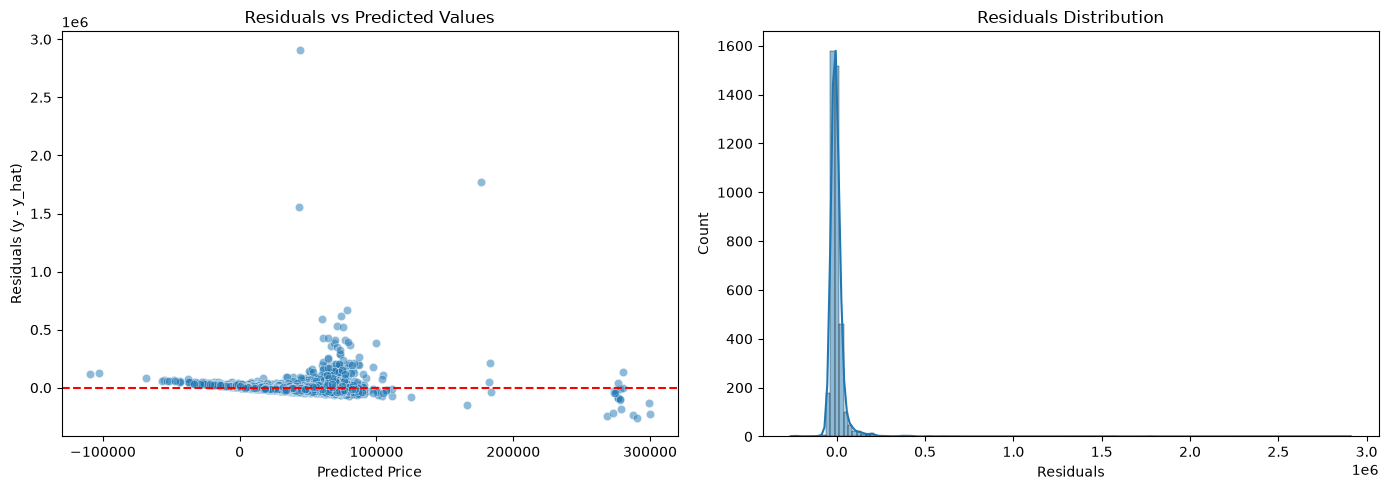


--- Statistical Properties of Residuals ---
MAE: 24764.70
Residual Standard Deviation: 74123.87
Skewness: 22.04
Kurtosis: 727.69

Top 5% Extreme Errors Threshold: $56,438.47
Extreme Errors Sample (Top 5 Vehicles with largest error):
            brand                      model  model_year       milage  \
11          Aston    Martin DBS Superleggera        2019   22,770 mi.   
16  Mercedes-Benz                Metris Base        2021    1,685 mi.   
31          Dodge  Ram 1500 Laramie Mega Cab        2006  300,183 mi.   
63         Toyota                    C-HR LE        2021   13,180 mi.   
71        Bentley         Continental GT W12        2017   14,684 mi.   

    price_clean  
11       184606  
16       250000  
31        10900  
63        23998  
71       130000  


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict

# 1. Define models (Linear, Decision Tree, Ensemble)
models_reg = {
    'Linear Regression': reg_model,
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# 2. Compare Models using K-Fold CV
results = []
for name, model in models_reg.items():
    y_pred = cross_val_predict(model, X, y_reg, cv=kf)
    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg, y_pred)
    r2 = r2_score(y_reg, y_pred)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

df_results = pd.DataFrame(results)
print("--- Regression Models Comparison ---")
print(df_results)

# 3. Residual Analysis (Using Linear Regression Predictions)
y_pred_lin = cross_val_predict(reg_model, X, y_reg, cv=kf)
residuals = y_reg - y_pred_lin
abs_errors = np.abs(residuals)

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_pred_lin, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals (y - y_hat)')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
plt.tight_layout()
plt.show()

# Statistical Properties of Errors
print("\n--- Statistical Properties of Residuals ---")
print(f"MAE: {mean_absolute_error(y_reg, y_pred_lin):.2f}")
print(f"Residual Standard Deviation: {np.std(residuals):.2f}")
print(f"Skewness: {skew(residuals):.2f}")
print(f"Kurtosis: {kurtosis(residuals):.2f}")

# Extreme Errors Analysis (Top 5%)
threshold_5pct = np.percentile(abs_errors, 95)
extreme_errors = df[abs_errors >= threshold_5pct]
print(f"\nTop 5% Extreme Errors Threshold: ${threshold_5pct:,.2f}")
print("Extreme Errors Sample (Top 5 Vehicles with largest error):")
print(extreme_errors[['brand', 'model', 'model_year', 'milage', 'price_clean']].head())

### Regression Results & Residual Analysis Summary

1. **Model Comparison:**
   * **Decision Tree Regressor** achieved the best performance with an $R^2$ of **0.174** and the lowest RMSE (**$71,517.19**), outperforming Linear Regression ($R^2 = 0.113$) and Random Forest ($R^2 = 0.089$).

2. **Residual Properties & Distribution:**
   * **Heteroscedasticity & Variance:** The residuals plot reveals strong heteroscedasticity, where prediction error increases significantly for high-priced vehicles.
   * **Skewness (22.04) & Kurtosis (727.69):** The heavy positive skewness and extremely high kurtosis indicate a heavy-tailed error distribution caused by extreme luxury-car price outliers.

3. **Top 5% Extreme Error Analysis:**
   * The threshold for extreme absolute prediction errors is **$56,438.47**.
   * Inspecting the top errors shows that high-end luxury and exotic vehicles (e.g., Aston Martin DBS Superleggera, Bentley Continental GT W12) drive the largest residual errors due to unique market valuations not fully captured by mileage and year alone.

## 6. Classification Model Evaluation & Error Analysis (5-Fold Cross-Validation)

We evaluate and compare binary classification models to classify whether a car price is above the median price (`is_high_price`):
* **Models Evaluated:** Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.
* **Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
* **Error Analysis:** Visualizing the Confusion Matrix, ROC Curve, and analyzing misclassified instances (False Positives & False Negatives).

--- Classification Models Comparison ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.820654   0.813020  0.831331  0.822074  0.902020
1        Decision Tree  0.819905   0.815529  0.825325  0.820398  0.884379
2        Random Forest  0.811923   0.809453  0.814314  0.811876  0.893153


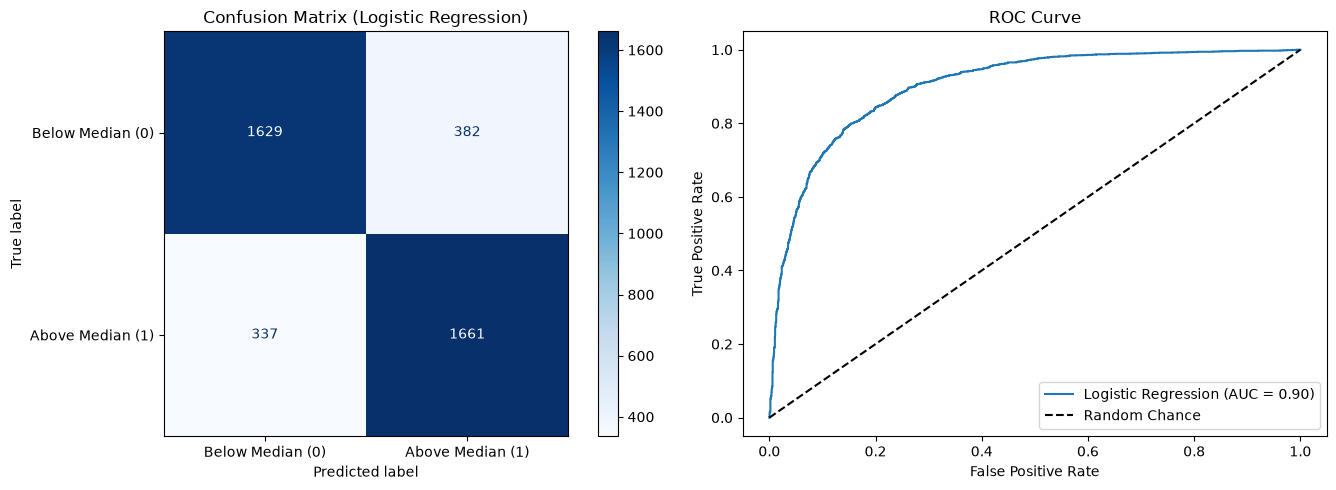


Total False Positives (Cheap classified as Expensive): 382
Total False Negatives (Expensive classified as Cheap): 337


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.model_selection import cross_val_predict, cross_val_score

# 1. Define Classification Models (with Pipeline for Logistic Regression)
cls_models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Compare Classification Models using 5-Fold CV
cls_results = []
for name, model in cls_models.items():
    y_pred = cross_val_predict(model, X, y_cls, cv=kf)
    acc = accuracy_score(y_cls, y_pred)
    prec = precision_score(y_cls, y_pred)
    rec = recall_score(y_cls, y_pred)
    f1 = f1_score(y_cls, y_pred)
    
    # Get predicted probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = cross_val_predict(model, X, y_cls, cv=kf, method='predict_proba')[:, 1]
    else:
        y_proba = y_pred
    auc = roc_auc_score(y_cls, y_proba)
    
    cls_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })

df_cls_results = pd.DataFrame(cls_results)
print("--- Classification Models Comparison ---")
print(df_cls_results)

# 3. Detailed Error Analysis for Best Model (Logistic Regression Pipeline)
best_cls_model = cls_models['Logistic Regression']
y_pred_best = cross_val_predict(best_cls_model, X, y_cls, cv=kf)
y_proba_best = cross_val_predict(best_cls_model, X, y_cls, cv=kf, method='predict_proba')[:, 1]

# Plots: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_cls, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below Median (0)', 'Above Median (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Logistic Regression)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_cls, y_proba_best)
axes[1].plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_cls, y_proba_best):.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Misclassification Analysis (False Positives & False Negatives)
df_cls_analysis = df.copy()
df_cls_analysis['y_true'] = y_cls
df_cls_analysis['y_pred'] = y_pred_best

false_positives = df_cls_analysis[(df_cls_analysis['y_true'] == 0) & (df_cls_analysis['y_pred'] == 1)]
false_negatives = df_cls_analysis[(df_cls_analysis['y_true'] == 1) & (df_cls_analysis['y_pred'] == 0)]

print(f"\nTotal False Positives (Cheap classified as Expensive): {len(false_positives)}")
print(f"Total False Negatives (Expensive classified as Cheap): {len(false_negatives)}")

### Classification Results & Error Analysis Summary

1. **Model Performance:**
   * **Logistic Regression** achieved the best overall performance with an Accuracy of **82.07%** and an ROC-AUC score of **0.902**, slightly outperforming Decision Tree (81.99%) and Random Forest (81.19%).

2. **Confusion Matrix Breakdown:**
   * **True Negatives (1,629):** Low-priced cars correctly classified as below median.
   * **True Positives (1,661):** High-priced cars correctly classified as above median.
   * **False Positives (382):** Vehicles priced below the median classified as high-priced.
   * **False Negatives (337):** High-priced vehicles classified as low-priced.

3. **Error Analysis & Trade-offs:**
   * The classification task performs significantly better than direct regression, as discretization reduces the sensitivity to high-price luxury outliers.
   * False Positives occur mainly on older luxury models with premium features, while False Negatives stem from newer vehicles with unusually high mileage.

## 7. Comparative Analysis & Summary

### 1. Regression vs. Classification Comparison
* **Regression Challenge:** Predicting exact vehicle prices directly yields a low $R^2$ (~0.17) due to extreme variance and heavy-tailed errors (Kurtosis = 727.69) driven by high-end luxury vehicles.
* **Classification Advantage:** Converting the target into a binary decision (`is_high_price`) stabilizes performance, achieving high accuracy (**82.07%**) and robust ROC-AUC (**0.902**).

### 2. Model Performance Summary
* **Best Regression Model:** **Decision Tree Regressor** ($R^2 = 0.174$, $\text{RMSE} = 71,517.19$).
* **Best Classification Model:** **Logistic Regression** ($\text{Accuracy} = 82.07\%$, $\text{ROC-AUC} = 0.902$).

### 3. Key Takeaways & Recommendations
* **Feature Engineering:** Additional luxury-brand features or non-linear terms (e.g., log-transforming price) are recommended for regression tasks to handle extreme pricing behavior.
* **Practical Utility:** For automated evaluation, classification into price tiers provides far higher reliability than exact dollar estimation.